# 01. ODE の全体像 — 状態が時間とともにどう変わるか

> 本書の読み方: **微分積分(00 章) → ODE → PDE → 応用**。
> この章は ODE 全体の地図です。まず 00 章で微分=変化率・積分=蓄積の直感を作ってから戻ってくると、
> 以下がすべて「変化率をルールとして与える」一つの考えに見えてきます。

| 層 | セクション |
|---|---|
| Basic | 1. Big Picture 〜 4. Visualization |
| Applied | 5. 解析解と数値解 〜 6. 読み方 |
| Advanced | 7. Advanced Notes |

## 1. Big Picture

**常微分方程式 (ODE)** は、たった一つのことを記述します。

> **状態が、時間とともにどう変わるか。**

未知関数 $y(t)$ そのものではなく、その **変化率** $dy/dt$ を、現在の状態と時刻の関数として与えます。

$$
\frac{dy}{dt} = f(t, y)
$$

「いまどこにいるか ($y$)」が決まれば「次にどちらへどれだけ動くか ($dy/dt$)」が決まる——
この **局所的なルール** を時間方向に積み上げると、未来の軌道が決まります。これが ODE の世界です。

## 2. Problem / 3. Intuition — なぜ微分方程式なのか

現実の多くの法則は「量そのもの」ではなく「量の変化のしかた」で表されます。

- 放射性物質: 残量が多いほど速く減る → $dy/dt = -k y$
- 人口: 余裕があるほど増えるが、上限に近づくと頭打ち → $dy/dt = r y(1 - y/K)$
- 運動: 力 = 質量 × 加速度(加速度は位置の二階微分) → $m\,\ddot{x} = F$

いずれも **変化率を状態で表す** 形をしています。ODE はこの形を解いて(あるいは数値積分して)、
時間発展を再構成する道具です。

In [1]:
# Shared setup. Make the book package importable whether or not it is pip-installed,
# then fix the random seed and tidy NumPy printing.
import sys
from pathlib import Path

try:
    import ode_book  # noqa: F401
except ModuleNotFoundError:
    for _base in (Path.cwd(), *Path.cwd().parents):
        if (_base / "src" / "ode_book").is_dir():
            sys.path.insert(0, str(_base / "src"))
            break

import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)
np.set_printoptions(precision=4, suppress=True)

In [2]:
from ode_book import systems, solvers, plotting, datasets

## 4. Visualization — 同じ法則から、無数の未来

$dy/dt = f(t,y)$ は各点で「傾き」を定めます。これを矢印で敷き詰めたものが **方向場 (slope field)** です。
解は、初期条件という出発点を一つ選び、方向場に沿って流れていく曲線です。
初期条件を変えると別の未来になりますが、**ルール(方向場)は共通** であることに注目してください。

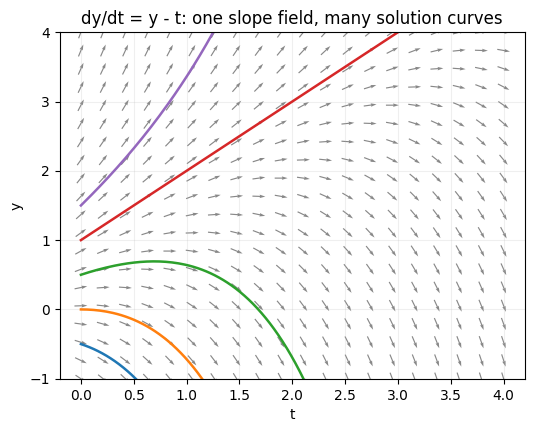

In [3]:
# One rule, many futures: the slope field of dy/dt = y - t with several solutions.
f = lambda t, y: y - t
ax = plotting.direction_field(f, (0, 4), (-1, 4), n=20)
import numpy as np
t = np.linspace(0, 4, 200)
for y0 in (-0.5, 0.0, 0.5, 1.0, 1.5):
    Y = solvers.rk4(f, [y0], t)
    ax.plot(t, Y[:, 0], lw=1.8)
ax.set_ylim(-1, 4)
ax.set_title("dy/dt = y - t: one slope field, many solution curves")
plt.show()

## 5. 解析解と数値解 (Applied)

ODE の解き方は二通りあります。

- **解析解**: 紙と鉛筆(または SymPy)で閉じた式を求める。可能なら最も理解が深い。
- **数値解**: 方向場に沿って小さく刻みながら前進する(Euler 法など)。ほとんどの実問題はこちら。

簡単な指数減衰 $dy/dt = -y$ で両者を比べます。解析解 $y = y_0 e^{-t}$ に、Euler 法と RK4 法が
どれだけ一致するかを見ます(詳しくは 06 章)。

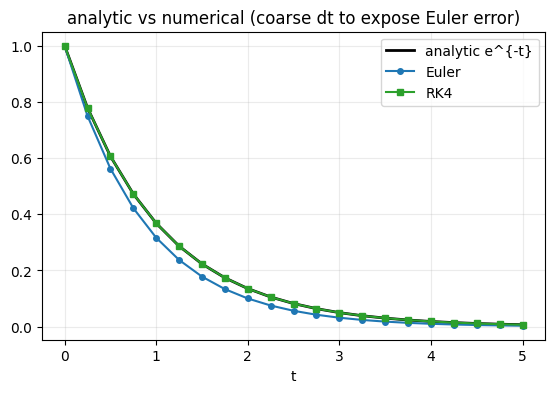

max |Euler - exact| = 0.051473191171442334
max |RK4   - exact| = 1.4758235306278067e-05


In [4]:
import numpy as np

# Analytic vs numerical on dy/dt = -y, y(0)=1  (exact: e^{-t}).
f = systems.exponential(-1.0)
t = np.linspace(0, 5, 21)
exact = np.exp(-t)
Y_euler = solvers.euler(f, [1.0], t)[:, 0]
Y_rk4 = solvers.rk4(f, [1.0], t)[:, 0]

fig, ax = plt.subplots(figsize=(6.5, 4))
ax.plot(t, exact, "k-", lw=2, label="analytic e^{-t}")
ax.plot(t, Y_euler, "o-", ms=4, color="#1f77b4", label="Euler")
ax.plot(t, Y_rk4, "s-", ms=4, color="#2ca02c", label="RK4")
ax.legend()
ax.grid(alpha=0.25)
ax.set_xlabel("t")
ax.set_title("analytic vs numerical (coarse dt to expose Euler error)")
plt.show()
print("max |Euler - exact| =", np.max(np.abs(Y_euler - exact)))
print("max |RK4   - exact| =", np.max(np.abs(Y_rk4 - exact)))

## 6. この教材の読み方

各章は次の流れを踏みます: **現象 → 直感 → 可視化 → 数式 → Python 実験 → 応用 → 発展**。
また各章は 3 層に分かれます。

- **Basic**: 初学者が最低限つかむべき直感と定義
- **Applied**: Python による実装・実験・応用
- **Advanced**: 証明・発展理論・数値上の注意(`Advanced Notes` に分離)

### 章構成 (ODE Book)

| Notebook | 内容 |
|---|---|
| `00_calculus_foundations` | 前提編: 微分=変化率 / 積分=蓄積 / 偏微分・勾配・Hessian |
| `01_overview` | ODE の全体像(この章) |
| `02_first_order_odes` | 一階 ODE・変数分離・線形一階・ロジスティック・方向場 |
| `03_linear_odes_and_systems` | 高階線形・連立 ODE・行列形式・固有値・振動 |
| `04_phase_plane_and_stability` | 相図・固定点・線形化・安定性分類・ヌルクライン |
| `05_nonlinear_dynamics` | Lotka-Volterra・SIR・分岐・カオスの入口(Lorenz) |
| `06_numerical_methods` | Euler/Heun/RK4・誤差と次数・安定性・stiff・solve_ivp |
| `07_applications_physics_biology_finance` | 物理・生物・金融・機械学習・制御 |

### Python 環境の準備

```bash
# この workspace 内(推奨)
cd ~/projects && make install

# 単体で使う場合
cd analytics/differential_equation/ode-book
python -m venv .venv && source .venv/bin/activate
pip install -r requirements.txt && pip install -e .
```

各 Notebook の最初のセルは、`ode_book` が未インストールでも `src/` を探して読み込む作りなので、
リポジトリを clone してそのまま実行できます。

## 7. Advanced Notes

- **次元(状態の数)**: スカラー ODE は 1 次元の状態。$n$ 個連立させると $n$ 次元の状態ベクトル
  $\mathbf{x}\in\mathbb{R}^n$ になり、$d\mathbf{x}/dt = \mathbf{f}(t,\mathbf{x})$ と書けます(03 章)。
- **自励系 (autonomous)**: $f$ が $t$ に陽に依らない $dy/dt=f(y)$。方向場が時間で変わらないので相図が描けます(04 章)。
- **存在と一意性**: $f$ が $y$ について Lipschitz 連続なら、初期値問題の解は局所的に一意に存在します
  (Picard–Lindelöf)。これが「初期条件を決めれば未来が一つに決まる」ことの数学的保証です。
- **高階 = 連立一階**: $y^{(n)} = g(t, y, y', \dots)$ は補助変数を導入して必ず一階の連立系に直せます。
  だから本書のソルバは一階系だけ扱えば十分です。